### Introduction

This notebook demonstrates the use of Bayesian models for classification tasks, focusing on Bayesian Logistic Regression and Bayesian Neural Networks. Bayesian methods provide a probabilistic approach to machine learning, allowing for uncertainty quantification in predictions, which is particularly useful in decision-making under uncertainty.

### Objectives

#### Train Bayesian models, including:
Bayesian Logistic Regression: A probabilistic version of logistic regression.
Bayesian Neural Networks: Neural networks with Bayesian inference for parameter estimation.

#### Evaluation:

Evaluate the performance of the models using metrics such as:
Accuracy: To measure the proportion of correct predictions.
ROC-AUC: To assess the model's ability to distinguish between classes.
Visualization:

Visualize the results, including decision boundaries and uncertainty estimates, to better understand the behavior of Bayesian models.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale

from pybandits.model import BayesianLogisticRegression, BayesianNeuralNetwork

%load_ext autoreload
%autoreload 2

In [2]:
def plot_map(value, grid, x_test, pred, metric):
    cmap = plt.get_cmap("coolwarm")

    fig, ax = plt.subplots(figsize=(10, 6))

    # Create the contour plot
    contour = ax.contourf(*grid, value.reshape(100, 100), cmap=cmap)

    # Scatter plot for the test points
    ax.scatter(x_test[pred == 0, 0], x_test[pred == 0, 1], label="Class 0")
    ax.scatter(x_test[pred == 1, 0], x_test[pred == 1, 1], color="r", label="Class 1")

    # Add a colorbar
    cbar = plt.colorbar(contour, ax=ax)
    cbar.ax.set_ylabel(f"Posterior predictive {metric} probability of class label = 1")

    # Set axis limits and labels
    ax.set(xlim=(-3, 3), ylim=(-3, 3), xlabel="X", ylabel="Y")

    # Add a legend
    ax.legend()

    plt.show()

## Generate data

In [3]:
X, Y = make_moons(noise=0.2, random_state=0, n_samples=1000)
X = scale(X)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.5)
y_train = y_train.tolist()
y_test = y_test.tolist()

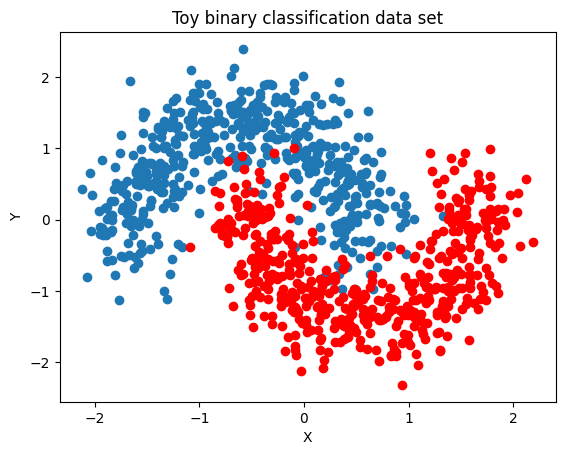

In [4]:
fig, ax = plt.subplots()
ax.scatter(X[Y == 0, 0], X[Y == 0, 1], label="Class 0")
ax.scatter(X[Y == 1, 0], X[Y == 1, 1], color="r", label="Class 1")
ax.set(xlabel="X", ylabel="Y", title="Toy binary classification data set");

## Using Bayesian logistic regression

In [5]:
blr = BayesianLogisticRegression.cold_start(num_features=2, update_method="VI", update_kwargs={"fit": {"n": 20000}})

In [6]:
blr.update(x_train, y_train)

Finished [100%]: Average Loss = 3,422.7


In [7]:
dummy_out = [1] * len(y_test)
_model = blr.create_model(x_test, dummy_out, is_sampelwise=True)
with _model:
    samples = pm.sample_prior_predictive(samples=500)

Sampling: [bias_0, out, weight_0]


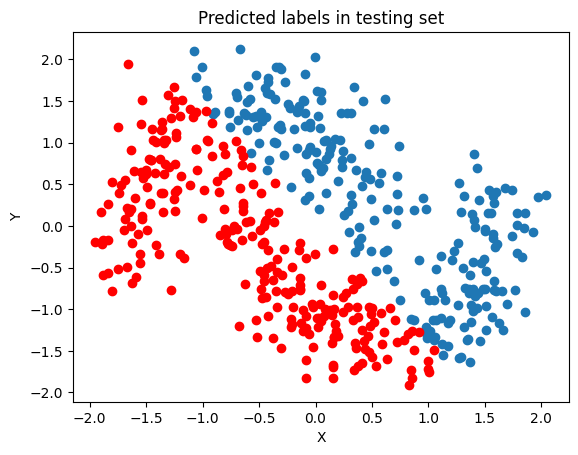

In [8]:
pred_proba = samples["prior_predictive"]["out"].squeeze().values.mean(axis=0)
pred = pred_proba > 0.5

fig, ax = plt.subplots()
ax.scatter(x_test[pred == 0, 0], x_test[pred == 0, 1])
ax.scatter(x_test[pred == 1, 0], x_test[pred == 1, 1], color="r")
ax.set(title="Predicted labels in testing set", xlabel="X", ylabel="Y");

In [9]:
# Calculate accuracy
accuracy = accuracy_score(y_test, pred)
print(f"Accuracy: {accuracy}")

# Calculate AUC
auc = roc_auc_score(y_test, pred_proba)
print(f"AUC: {auc}")

Accuracy: 0.554
AUC: 0.5601209619353911


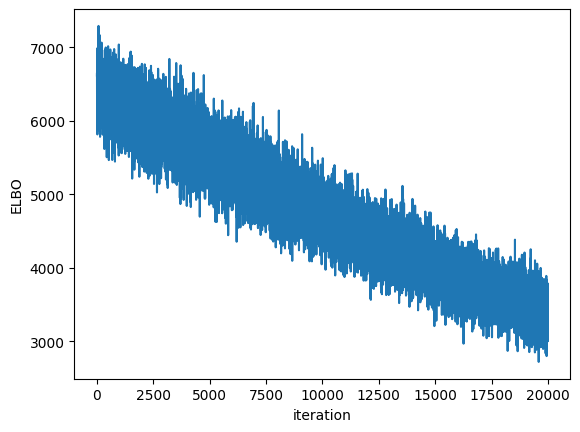

In [10]:
plt.plot(blr._approx.hist)
plt.ylabel("ELBO")
plt.xlabel("iteration")
plt.show()

### Predictions + uncertainty map

In [11]:
grid = np.mgrid[-3:3:100j, -3:3:100j].astype(float)
grid_2d = grid.reshape(2, -1).T
grid_label = np.ones(grid_2d.shape[0], dtype=np.int8).tolist()

In [12]:
_model = blr.create_model(grid_2d, grid_label, is_sampelwise=True)
with _model:
    samples = pm.sample_prior_predictive(samples=500)

Sampling: [bias_0, out, weight_0]


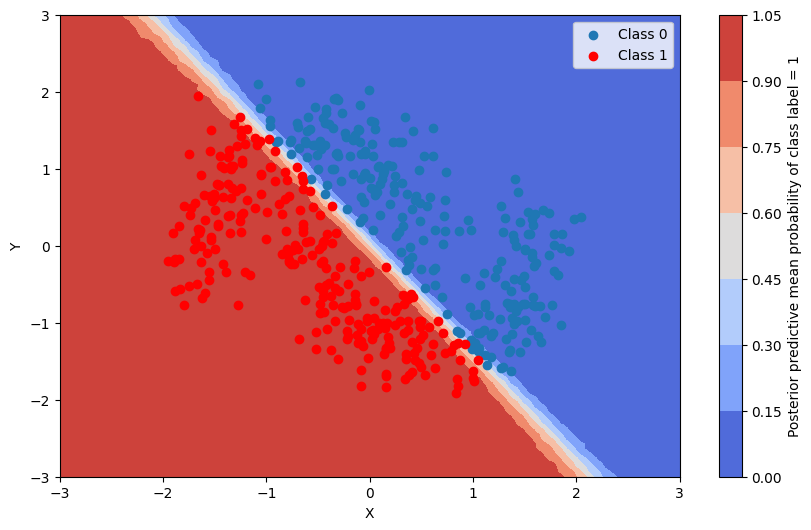

In [13]:
prob = samples["prior_predictive"]["out"].squeeze().values.mean(axis=0)
plot_map(prob, grid, x_test, pred, "mean")

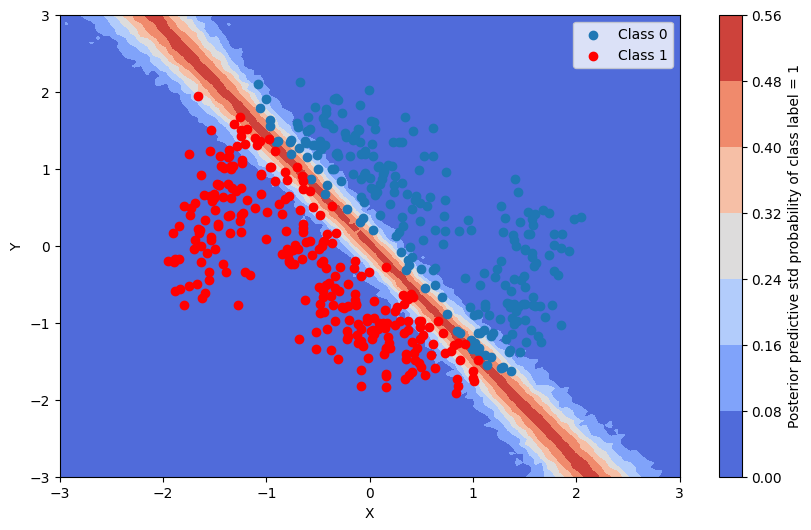

In [14]:
std = samples["prior_predictive"]["out"].squeeze().values.std(axis=0)
plot_map(std, grid, x_test, pred, "std")

## Using Bayesian Neural Network

In [15]:
dist_params_init = {"mu": 0, "sigma": 1, "nu": 5}
bnn = BayesianNeuralNetwork.cold_start(
    num_features=2,
    hidden_dim_list=[5, 5],
    update_method="VI",
    dist_params_init=dist_params_init,
    update_kwargs={"fit": {"n": 100000}},
)

In [16]:
bnn.update(x_train, y_train)

Finished [100%]: Average Loss = 119.66


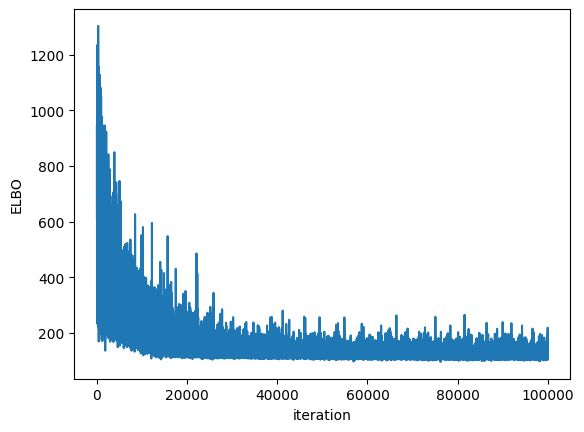

In [17]:
plt.plot(bnn._approx.hist)
plt.ylabel("ELBO")
plt.xlabel("iteration")
plt.show()

Sampling: [bias_0, bias_1, bias_2, out, weight_0, weight_1, weight_2]


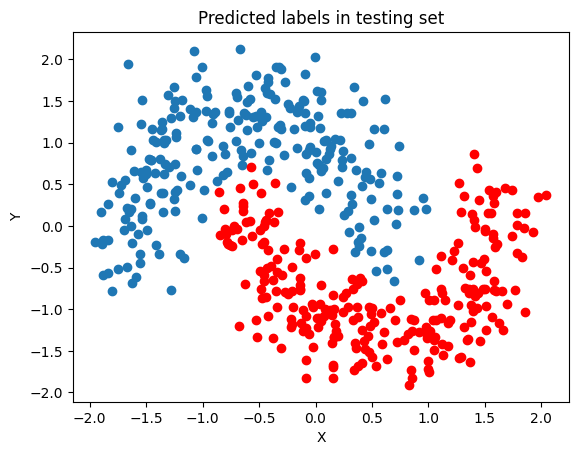

In [18]:
dummy_out = [1] * len(y_test)
_model = bnn.create_model(x_test, dummy_out, is_sampelwise=True)
with _model:
    samples = pm.sample_prior_predictive(samples=500)

pred_proba = samples["prior_predictive"]["out"].squeeze().values.mean(axis=0)
pred = pred_proba > 0.5

fig, ax = plt.subplots()
ax.scatter(x_test[pred == 0, 0], x_test[pred == 0, 1])
ax.scatter(x_test[pred == 1, 0], x_test[pred == 1, 1], color="r")
ax.set(title="Predicted labels in testing set", xlabel="X", ylabel="Y");

In [19]:
# Calculate accuracy
accuracy = accuracy_score(y_test, pred)
print(f"Accuracy: {accuracy}")

# Calculate AUC
auc = roc_auc_score(y_test, pred_proba)
print(f"AUC: {auc}")

Accuracy: 0.972
AUC: 0.995335925374806


### Predictions + uncertainty map

In [20]:
grid = np.mgrid[-3:3:100j, -3:3:100j].astype(float)
grid_2d = grid.reshape(2, -1).T
grid_label = np.ones(grid_2d.shape[0], dtype=np.int8).tolist()

In [21]:
_model = bnn.create_model(grid_2d, grid_label, is_sampelwise=True)
with _model:
    samples = pm.sample_prior_predictive(samples=500)

Sampling: [bias_0, bias_1, bias_2, out, weight_0, weight_1, weight_2]


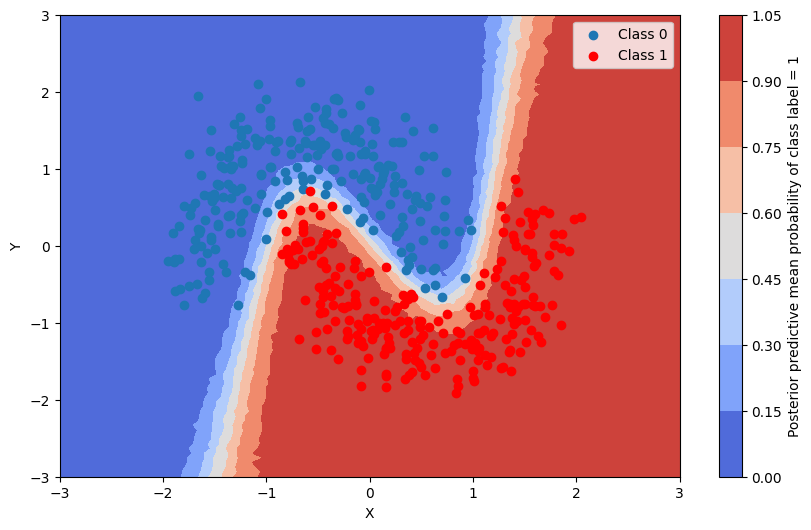

In [22]:
mean = samples["prior_predictive"]["out"].squeeze().values.mean(axis=0)
plot_map(mean, grid, x_test, pred, "mean")

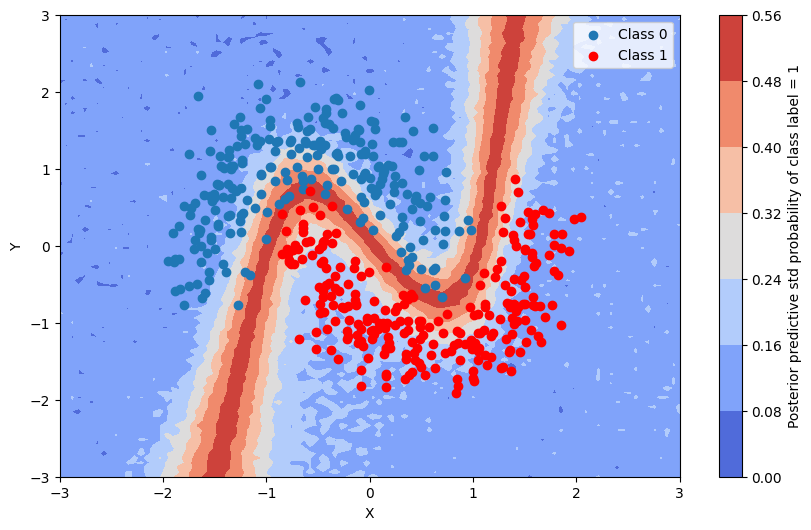

In [23]:
std = samples["prior_predictive"]["out"].squeeze().values.std(axis=0)
plot_map(std, grid, x_test, pred, "std")